# Real / Imaginary MP-PCA Denoising

Gaussian noise가 추가된 multi-echo GRE complex 데이터를 Real과 Imaginary 성분으로 나누어 각각 독립적으로 MP-PCA denoising을 수행한다.

Real과 Imaginary 데이터에는 음수 값이 존재할 수 있으므로, DIPY의 `localpca.py`를 기반으로 non-negative clipping 부분을 제거한 `localpca_dn.py`의 `mppca()`를 사용한다.

Denoising 후 Real과 Imaginary를 다시 결합하여 complex 데이터를 생성하고, magnitude 영상을 통해 원본 및 noisy 데이터와 비교한다.


In [2]:
import numpy as np
import scipy.io as sio
import matplotlib.pyplot as plt
from pathlib import Path

from localpca_dn import mppca

### 환경설정

In [4]:
NOISE_LEVELS = [10, 30, 50]
PATCH_R = 2

NOISY_DIR = Path("./data/noisy_data")
OUT_DIR = Path("./data/denoised/real_imag")

OUT_DIR.mkdir(parents=True, exist_ok=True)

### 1. Noise 데이터 불러오기

In [6]:
noisy_datasets = {}

for noise_level in NOISE_LEVELS:
    noisy_path = (
        NOISY_DIR /
        f"noisy_meas_gre_dir1_{noise_level}.mat"
    )

    noisy_data = sio.loadmat(
        noisy_path,
        simplify_cells=True
    )

    noisy_real = noisy_data["noisy_real"].astype(np.float32)
    noisy_imag = noisy_data["noisy_imag"].astype(np.float32)
    mask = noisy_data["mask_brain"].astype(bool)

    noisy_datasets[noise_level] = {
        "noisy_real": noisy_real,
        "noisy_imag": noisy_imag,
        "mask": mask,
        "metadata": noisy_data,
    }

    print(f"{noise_level}% noise 데이터 로드 완료")
    print("Real shape :", noisy_real.shape)
    print("Imag shape :", noisy_imag.shape)

10% noise 데이터 로드 완료
Real shape : (256, 224, 176, 6)
Imag shape : (256, 224, 176, 6)
30% noise 데이터 로드 완료
Real shape : (256, 224, 176, 6)
Imag shape : (256, 224, 176, 6)
50% noise 데이터 로드 완료
Real shape : (256, 224, 176, 6)
Imag shape : (256, 224, 176, 6)


### 2. Real MP-PCA Denoising

In [8]:
deno_real_data = {}

for noise_level in NOISE_LEVELS:
    noisy_real = noisy_datasets[noise_level]["noisy_real"]
    mask = noisy_datasets[noise_level]["mask"]

    print("\n" + "=" * 50)
    print(f"Noise level : {noise_level}%")
    print("Real MP-PCA denoising")
    print("=" * 50)

    deno_real = mppca(
        noisy_real,
        mask=mask,
        patch_radius=PATCH_R
    )

    deno_real_data[noise_level] = deno_real

    print(f"{noise_level}% Real denoising 완료")



Noise level : 10%
Real MP-PCA denoising


C:\Users\653wa\git\Graduation-Thesis\Research-Reimplementation\localpca_dn.py:376: RuntimeWarning: invalid value encountered in divide
  denoised_arr = thetax / theta


10% Real denoising 완료

Noise level : 30%
Real MP-PCA denoising
30% Real denoising 완료

Noise level : 50%
Real MP-PCA denoising
50% Real denoising 완료


### 3. Imaginary MP-PCA Denoising

In [10]:
deno_imag_data = {}

for noise_level in NOISE_LEVELS:
    noisy_imag = noisy_datasets[noise_level]["noisy_imag"]
    mask = noisy_datasets[noise_level]["mask"]

    print("\n" + "=" * 50)
    print(f"Noise level : {noise_level}%")
    print("Imaginary MP-PCA denoising")
    print("=" * 50)

    deno_imag = mppca(
        noisy_imag,
        mask=mask,
        patch_radius=PATCH_R
    )

    deno_imag_data[noise_level] = deno_imag

    print(f"{noise_level}% Imaginary denoising 완료")


Noise level : 10%
Imaginary MP-PCA denoising
10% Imaginary denoising 완료

Noise level : 30%
Imaginary MP-PCA denoising
30% Imaginary denoising 완료

Noise level : 50%
Imaginary MP-PCA denoising
50% Imaginary denoising 완료


### 4. Real / Imaginary 재결합

In [12]:
denoised_data = {}

for noise_level in NOISE_LEVELS:
    deno_real = deno_real_data[noise_level]
    deno_imag = deno_imag_data[noise_level]

    deno_complex = (
        deno_real.astype(np.complex64)
        + 1j * deno_imag.astype(np.complex64)
    )

    denoised_data[noise_level] = {
        "deno_real": deno_real,
        "deno_imag": deno_imag,
        "deno_complex": deno_complex,
    }

    print(f"{noise_level}% complex 재결합 완료")


10% complex 재결합 완료
30% complex 재결합 완료
50% complex 재결합 완료


### 5. 결과 저장

In [14]:
for noise_level in NOISE_LEVELS:
    noisy_data = noisy_datasets[noise_level]["metadata"]

    deno_real = denoised_data[noise_level]["deno_real"]
    deno_imag = denoised_data[noise_level]["deno_imag"]
    deno_complex = denoised_data[noise_level]["deno_complex"]

    output_path = (
        OUT_DIR /
        f"denoised_real_imag_{noise_level}_r{PATCH_R}.mat"
    )

    save_data = {
        "deno_real": deno_real,
        "deno_imag": deno_imag,
        "deno_complex": deno_complex,
        "mask_brain": noisy_data["mask_brain"],
        "noise_level": noise_level,
        "patch_radius": PATCH_R,
        "te_gre": noisy_data["te_gre"],
        "delta_TE": noisy_data["delta_TE"],
        "voxel_size_gre": noisy_data["voxel_size_gre"],
        "B0_dir": noisy_data["B0_dir"],
        "CF": noisy_data["CF"],
    }

    sio.savemat(
        output_path,
        save_data
    )

    print("저장 완료 →", output_path)

저장 완료 → data\denoised\real_imag\denoised_real_imag_10_r2.mat
저장 완료 → data\denoised\real_imag\denoised_real_imag_30_r2.mat
저장 완료 → data\denoised\real_imag\denoised_real_imag_50_r2.mat


### 6. 시각화

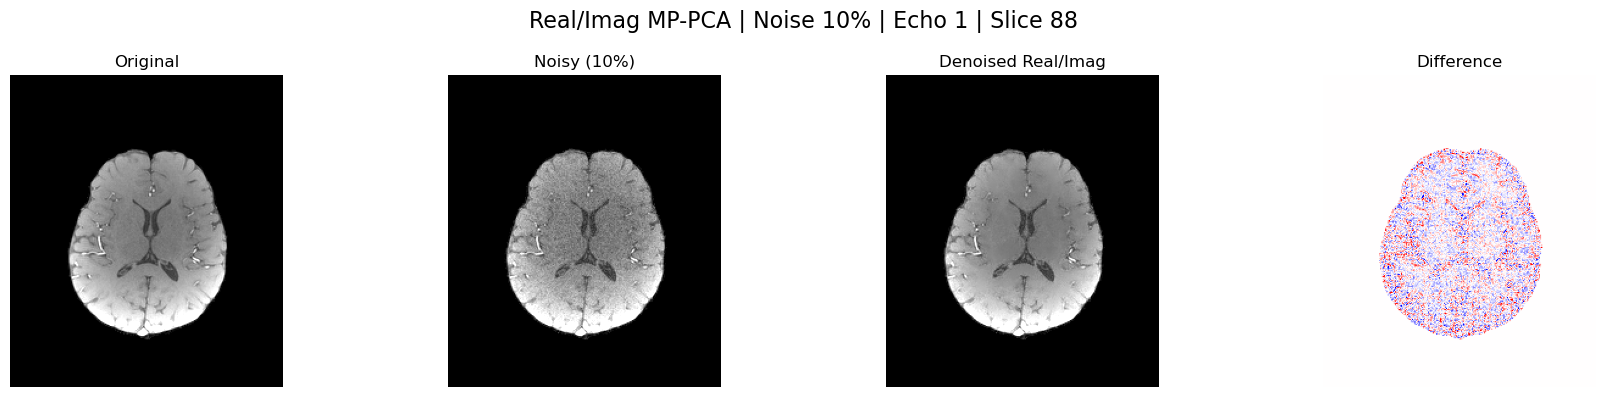

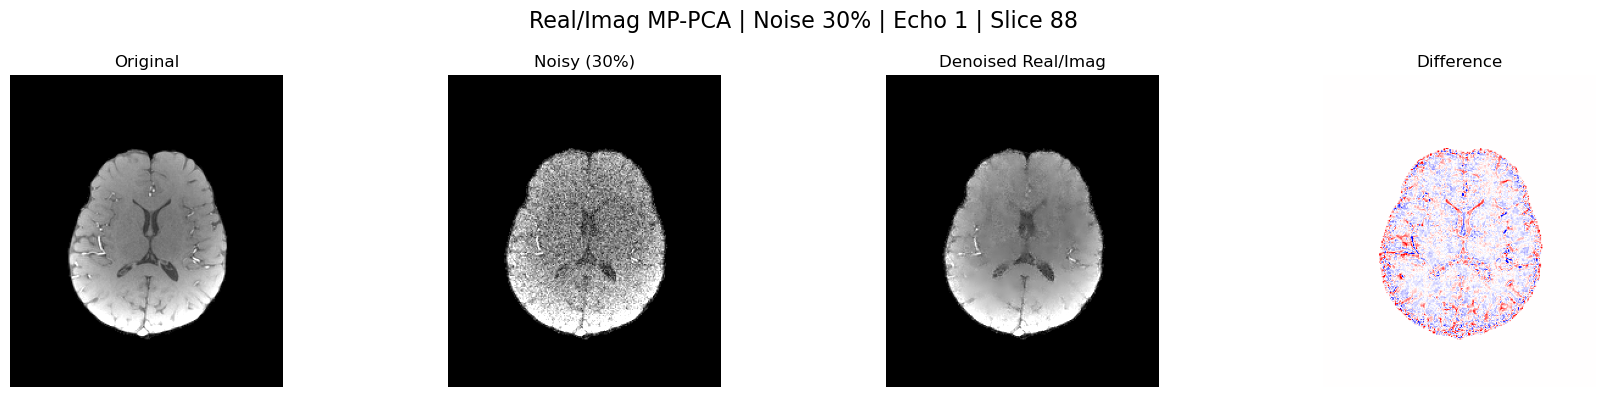

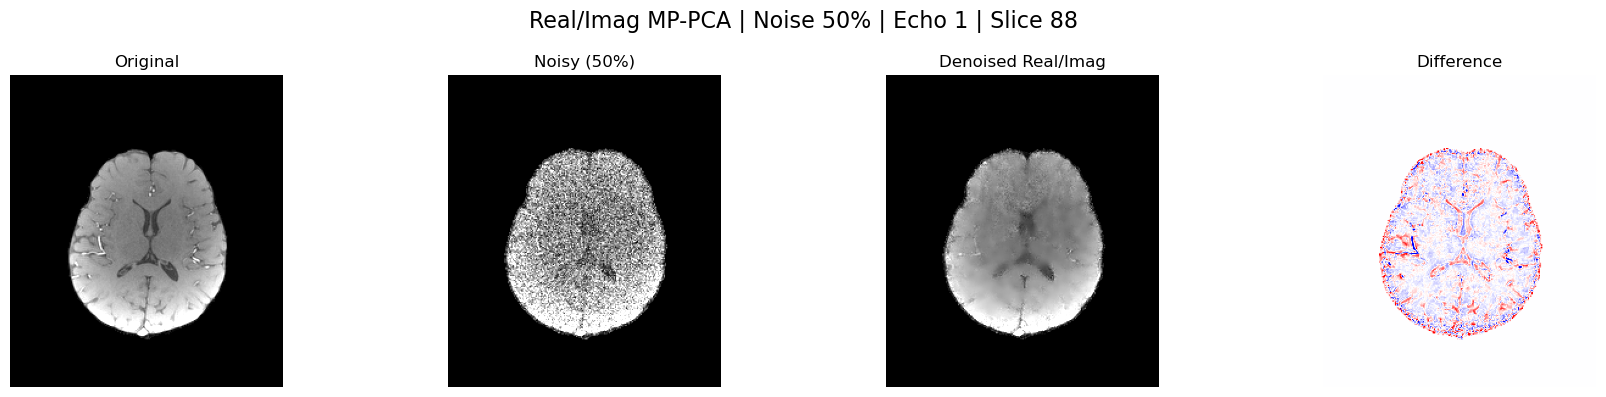

In [16]:
orig_data = sio.loadmat(
    "./data/meas_gre_dir1.mat",
    simplify_cells=True
)

orig_complex = orig_data["meas_gre"]
orig_mag = np.abs(orig_complex).astype(np.float32)

echo_idx = 0
slice_idx = 88

for noise_level in NOISE_LEVELS:
    noisy_real = noisy_datasets[noise_level]["noisy_real"]
    noisy_imag = noisy_datasets[noise_level]["noisy_imag"]
    mask = noisy_datasets[noise_level]["mask"]

    noisy_complex = (
        noisy_real.astype(np.complex64)
        + 1j * noisy_imag.astype(np.complex64)
    )

    deno_complex = denoised_data[noise_level]["deno_complex"]

    noisy_mag = np.abs(noisy_complex).astype(np.float32)
    deno_mag = np.abs(deno_complex).astype(np.float32)

    orig_2d = orig_mag[:, :, slice_idx, echo_idx]
    noisy_2d = noisy_mag[:, :, slice_idx, echo_idx]
    deno_2d = deno_mag[:, :, slice_idx, echo_idx]

    mask_2d = mask[:, :, slice_idx]

    diff_2d = deno_2d - orig_2d

    vmin, vmax = np.percentile(
        orig_mag[mask],
        (1, 99)
    )

    dv = np.percentile(
        np.abs(diff_2d[mask_2d]),
        99
    )

    fig, ax = plt.subplots(
        1,
        4,
        figsize=(18, 4)
    )

    ax[0].imshow(
        orig_2d,
        cmap="gray",
        vmin=vmin,
        vmax=vmax
    )
    ax[0].set_title("Original")
    ax[0].axis("off")

    ax[1].imshow(
        noisy_2d,
        cmap="gray",
        vmin=vmin,
        vmax=vmax
    )
    ax[1].set_title(f"Noisy ({noise_level}%)")
    ax[1].axis("off")

    ax[2].imshow(
        deno_2d,
        cmap="gray",
        vmin=vmin,
        vmax=vmax
    )
    ax[2].set_title("Denoised Real/Imag")
    ax[2].axis("off")

    ax[3].imshow(
        diff_2d,
        cmap="bwr",
        vmin=-dv,
        vmax=dv
    )
    ax[3].set_title("Difference")
    ax[3].axis("off")

    fig.suptitle(
        f"Real/Imag MP-PCA | Noise {noise_level}% | "
        f"Echo {echo_idx + 1} | Slice {slice_idx}",
        fontsize=16
    )

    plt.tight_layout()
    plt.show()